<a href="https://colab.research.google.com/github/Darlonss/Machine-Learning---qualidade-industrial-Rodrigo-Alonso-Santos-de-Sousa---221029365-/blob/main/Trabalho%201%20%7C%20SECOM%20-%20MVP%20%7C%20Rodrigo%20Alonso%20(221029365).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [2]:
url_data   = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
url_labels = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

X = pd.read_csv(url_data, sep=' ', header=None)
y_df = pd.read_csv(url_labels, sep=' ', header=None)

y = y_df[0].values  # coluna 0 = pass/fail (-1 ou 1)

print(f"Shape X: {X.shape}")
print(f"Distribuição das classes:\n{pd.Series(y).value_counts()}")

Shape X: (1567, 590)
Distribuição das classes:
-1    1463
 1     104
Name: count, dtype: int64


In [3]:
# 1. Remover colunas constantes (desvio padrão zero)
cols_constantes = X.columns[X.std() == 0]
X = X.drop(columns=cols_constantes)
print(f"Colunas constantes removidas: {len(cols_constantes)}")

# 2. Remover colunas com mais de 50% de NaN
thresh = len(X) * 0.5
X = X.dropna(thresh=thresh, axis=1)
print(f"Shape após remoção de colunas com >50% NaN: {X.shape}")

# 3. Imputar NaN restantes com a mediana
X = X.fillna(X.median())

print(f"Valores ausentes restantes: {X.isna().sum().sum()}")

Colunas constantes removidas: 116
Shape após remoção de colunas com >50% NaN: (1567, 446)
Valores ausentes restantes: 0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Classes no treino: {pd.Series(y_train).value_counts().to_dict()}")

Treino: (1253, 446) | Teste: (314, 446)
Classes no treino: {-1: 1170, 1: 83}


In [5]:
modelos = {
    "Logistic Regression (baseline)": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=1000))
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=SEED))
    ]),
    "Gradient Boosting": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf", GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ])
}

In [6]:
resultados = {}

for nome, pipeline in modelos.items():
    print(f"\n{'='*50}")
    print(f"Modelo: {nome}")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred, target_names=["Aprovado (-1)", "Reprovado (1)"]))

    resultados[nome] = {
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "recall_falha": recall_score(y_test, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }


Modelo: Logistic Regression (baseline)
               precision    recall  f1-score   support

Aprovado (-1)       0.94      0.89      0.91       293
Reprovado (1)       0.09      0.14      0.11        21

     accuracy                           0.84       314
    macro avg       0.51      0.52      0.51       314
 weighted avg       0.88      0.84      0.86       314


Modelo: Random Forest
               precision    recall  f1-score   support

Aprovado (-1)       0.93      1.00      0.96       293
Reprovado (1)       0.00      0.00      0.00        21

     accuracy                           0.93       314
    macro avg       0.47      0.50      0.48       314
 weighted avg       0.87      0.93      0.90       314


Modelo: Gradient Boosting
               precision    recall  f1-score   support

Aprovado (-1)       0.93      0.99      0.96       293
Reprovado (1)       0.00      0.00      0.00        21

     accuracy                           0.92       314
    macro avg       0.

                                f1_macro  recall_falha   roc_auc
Random Forest                   0.481848      0.000000  0.833333
Gradient Boosting               0.479270      0.000000  0.705835
Logistic Regression (baseline)  0.511788      0.142857  0.626849


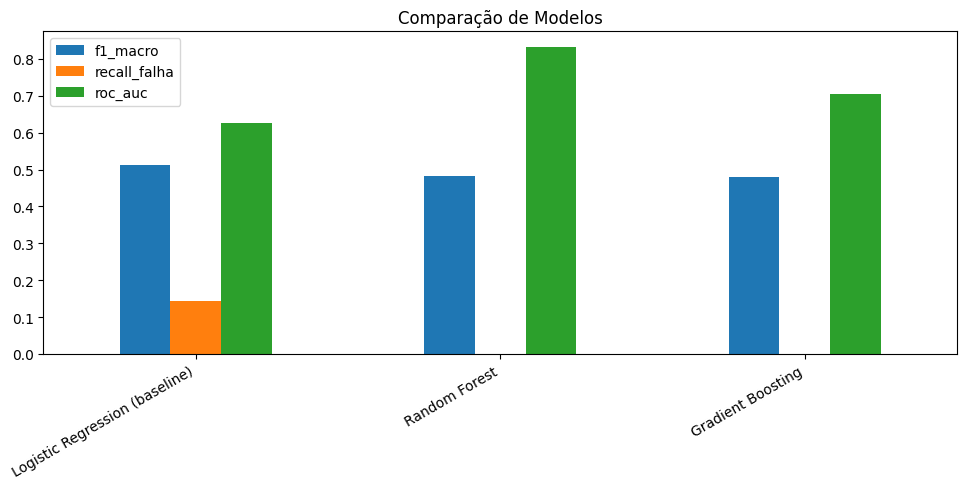

In [7]:
df_resultados = pd.DataFrame(resultados).T
print(df_resultados.sort_values("roc_auc", ascending=False))

df_resultados.plot(kind="bar", figsize=(10, 5), title="Comparação de Modelos")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [8]:
param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10]
}

pipeline_rf = ImbPipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=SEED))
])

search = RandomizedSearchCV(
    pipeline_rf, param_dist,
    n_iter=10, cv=StratifiedKFold(5),
    scoring="f1_macro", random_state=SEED, n_jobs=-1, verbose=1
)

search.fit(X_train, y_train)
print(f"Melhores parâmetros: {search.best_params_}")

y_pred_best = search.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["Aprovado (-1)", "Reprovado (1)"]))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhores parâmetros: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__max_depth': 10}
               precision    recall  f1-score   support

Aprovado (-1)       0.93      0.99      0.96       293
Reprovado (1)       0.00      0.00      0.00        21

     accuracy                           0.92       314
    macro avg       0.47      0.49      0.48       314
 weighted avg       0.87      0.92      0.90       314

